# Understanding Privacy Attitudes in E-Commerce: A Multi-Factor Analysis
## Predicting User Privacy Preferences from Amazon Shopping Behavior

**Author:** Angelina Grace Harrington    
**Date:** February 11 2026    
**Dataset:** Harvard Dataverse - [Open e-commerce 1.0](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY)

---

## Executive Summary

This project investigates the factors that predict whether Amazon customers are willing to allow the company to sell their personal purchase data to third parties. Using logistic regression on real-world survey and transaction data, Analyze how shopping behavior (spending, purchase patterns, product categories) and demographics jointly predict privacy attitudes.

**Key Findings:**
- Heavy Amazon spenders are 15% LESS privacy-conscious (OR=0.85, p<0.001) - counter-intuitive finding suggesting platform loyalty reduces privacy concern
- Sensitive product purchases show marginal positive effect (OR=1.20, p=0.061) - trend toward higher privacy concern among health/beauty buyers
- Purchase diversity and recency show no meaningful relationship with privacy attitudes
- Spending behavior is a stronger predictor than shopping patterns 



---

## Table of Contents
1. [Data Loading](#1-data-loading)
2. [Feature Engineering](#2-feature-engineering)
3. [Exploratory Data Analysis](#3-eda)
4. [Model Building](#4-modeling)
5. [Results & Interpretation](#5-results)
6. [Model Diagnostics](#6-diagnostics)
7. [Summary](#7-conclusions)
   





---
## Research Question 
What factors predict whether Amazon customers are willing to let the company sell their purchase data? Analyze real shopping behavior and survey responses to understand this relationship.


---
## Hypotheses 

### H1: Total Spending
> Users who spend more money on Amazon will have different privacy attitudes than light spenders.

### H2: Sensitive Product Purchases
> Users who purchase sensitive products (health, personal care, adult items) will be LESS willing to allow data sharing.

### H3: Purchase Diversity
> Users who shop across many product categories will have different privacy attitudes than specialized shoppers.

### H4: Purchase Recency
> Users who made recent purchases will be MORE privacy-conscious than inactive users.

### H5: Demographics (Control Variables)
> Age, income, and education will predict privacy attitudes independent of shopping behavior.


### Statistical Framework

**Null Hypothesis (H₀)**: None of the shopping behavior variables are associated with privacy attitudes after controlling for demographics.

**Alternative Hypothesis (H₁)**: At least one shopping behavior variable is significantly associated with privacy attitudes after controlling for demographics.

**Significance Level**: α = 0.05

**Method**: Logistic regression with progressive model building to test the incremental contribution of each factor.

---
## Data Overview 

### Data Sources

This analysis uses two datasets from the Harvard Dataverse [Open e-commerce 1.0](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY) study:

1. **Survey Data (`survey.csv`)**: 
   - Privacy attitudes and demographic information
   - N = 5,027 respondents
   - Key variables: Privacy preference, age, income, education

2. **Purchase Data (`amazon-purchases.csv`)**: 
   - Actual Amazon transaction records linked to survey respondents
   - N = 1,850,717 transactions 
   - Key variables: Order date, product title, category, price, quantity

### Outcome Variable

**Privacy Attitude** (Binary):
- `1` = "I am NOT comfortable with Amazon selling my purchase data"
- `0` = "I am comfortable with Amazon selling my purchase data"



---
## 1. Data Loading
<a id='1-data-loading'></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Load data
survey_df = pd.read_csv("survey.csv")
purchases_df = pd.read_csv("amazon-purchases.csv")

print(f"\nSurvey responses: {len(survey_df):,}")
print(f"Purchase records: {len(purchases_df):,}")
print(f"Unique shoppers: {purchases_df['Survey ResponseID'].nunique():,}")


Survey responses: 5,027
Purchase records: 1,850,717
Unique shoppers: 5,027


In [51]:
# Check privacy variable
print("\nPrivacy variable distribution:")
print(survey_df['Q-sell-YOUR-data'].value_counts())

# Check for health/personal care categories
sensitive_keywords = ['HEALTH', 'PERSONAL', 'BEAUTY', 'VITAMIN', 'SUPPLEMENT', 'DRUG']
categories = purchases_df['Category'].unique()
sensitive_cats = [cat for cat in categories if cat is not None and any(word in str(cat).upper() for word in sensitive_keywords)]
print("\nPotential sensitive categories:")
print(sensitive_cats)


Privacy variable distribution:
Q-sell-YOUR-data
Yes if I get part of the profit    2535
No                                 2142
Yes                                 194
I don't know                        156
Name: count, dtype: int64

Potential sensitive categories:
['HEALTH_PERSONAL_CARE', 'BEAUTY', 'GUILD_BEAUTY_GROOMING', 'PROFESSIONAL_HEALTHCARE', 'HERBAL_SUPPLEMENT', 'NUTRITIONAL_SUPPLEMENT', 'VITAMIN', 'MINERAL_SUPPLEMENT', 'PERSONAL_PILL_DISPENSER', 'ANIMAL_VITAMIN', 'PERSONAL_FRAGRANCE', 'PERSONAL_COMPUTER', 'PERSONAL_CARE_APPLIANCE', 'ANIMAL_NUTRITIONAL_SUPPLEMENT', 'PROTEIN_SUPPLEMENT_POWDER', 'DIETARY_SUPPLEMENTS', 'PERSONAL_FLOTATION_DEVICE', 'PET_HEALTH_CARE', 'LUXURY_BEAUTY', 'ABIS_DRUGSTORE', 'HEALTH_FOOD', 'Health and Beauty', 'ABIS_BEAUTY', 'Personal Computers']


---
<a id='2-feature-engineering'></a>
## 2. Feature Engineering
> Create behavioral variables from purchase data and prepare for modeling

### Defining Binary Outcome Variable

In [52]:
# Create Binary Outcome Variable
# Convert privacy attitude to binary: 1 = privacy-conscious, 0 = willing to share
survey_df['privacy_concerned'] = (survey_df['Q-sell-YOUR-data'] == 'No').astype(int)
print("Privacy Outcome Variable:")
print(f"Privacy-conscious (No): {survey_df['privacy_concerned'].sum():,} ({survey_df['privacy_concerned'].mean()*100:.1f}%)")
print(f"Willing to share: {(~survey_df['privacy_concerned'].astype(bool)).sum():,} ({(1-survey_df['privacy_concerned'].mean())*100:.1f}%)")


# Sensitive Product Categories
sensitive_categories = [
    'HEALTH_PERSONAL_CARE', 'BEAUTY', 'GUILD_BEAUTY_GROOMING', 
    'PROFESSIONAL_HEALTHCARE', 'HERBAL_SUPPLEMENT', 'NUTRITIONAL_SUPPLEMENT',
    'VITAMIN', 'MINERAL_SUPPLEMENT', 'PERSONAL_PILL_DISPENSER',
    'PERSONAL_FRAGRANCE', 'PERSONAL_CARE_APPLIANCE', 'PROTEIN_SUPPLEMENT_POWDER',
    'DIETARY_SUPPLEMENTS', 'LUXURY_BEAUTY', 'ABIS_DRUGSTORE', 'HEALTH_FOOD',
    'Health and Beauty', 'ABIS_BEAUTY'
]

print(f"\nIdentified {len(sensitive_categories)} sensitive categories")

Privacy Outcome Variable:
Privacy-conscious (No): 2,142 (42.6%)
Willing to share: 2,885 (57.4%)

Identified 18 sensitive categories


---
### Aggregate Purchase to User Level

In [53]:
purchases_df['Order Date'] = pd.to_datetime(purchases_df['Order Date'])

reference_date = purchases_df['Order Date'].max()
print(f"\nReference date (most recent purchase): {reference_date.strftime('%Y-%m-%d')}")
purchases_df['item_total'] = purchases_df['Purchase Price Per Unit'] * purchases_df['Quantity']
# Create features
user_features = purchases_df.groupby('Survey ResponseID').agg(
    total_spend=('item_total', 'sum'),
    num_transactions=('item_total', 'count'),
    num_items=('Quantity', 'sum'),
    num_categories=('Category', 'nunique'),
    last_purchase_date=('Order Date', 'max'),
    avg_item_price=('Purchase Price Per Unit', 'mean')
).reset_index()

user_features['days_since_purchase'] = (reference_date - user_features['last_purchase_date']).dt.days

# Flag users who purchased sensitive products
sensitive_purchasers = purchases_df[purchases_df['Category'].isin(sensitive_categories)]['Survey ResponseID'].unique()
user_features['has_sensitive_purchases'] = user_features['Survey ResponseID'].isin(sensitive_purchasers).astype(int)

# Merge survey responses with behavioral features
analysis_df = survey_df.merge(user_features, on='Survey ResponseID', how='inner')



Reference date (most recent purchase): 2024-08-15


---
### Data Cleaning

In [54]:
# Check for missing values in key variables
key_vars = ['privacy_concerned', 'total_spend', 'has_sensitive_purchases', 
            'num_categories', 'days_since_purchase', 'Q-demos-age', 
            'Q-demos-education', 'Q-demos-income']

for var in key_vars:
    missing = analysis_df[var].isnull().sum()
    if missing > 0:
        print(f"{var}: {missing} ({missing/len(analysis_df)*100:.1f}%)")

# Remove rows with missing values in key variables
analysis_df_clean = analysis_df[key_vars].dropna()

print(f"\nFinal analysis sample: {len(analysis_df_clean):,} users")
print(f"Dropped {len(analysis_df) - len(analysis_df_clean):,} rows due to missing data")



Final analysis sample: 5,027 users
Dropped 0 rows due to missing data


---
### Log-Transformation

Original spending: Mean=$8,763.40, Median=$5,706.99
Log-transformed: Mean=8.46, Median=8.65


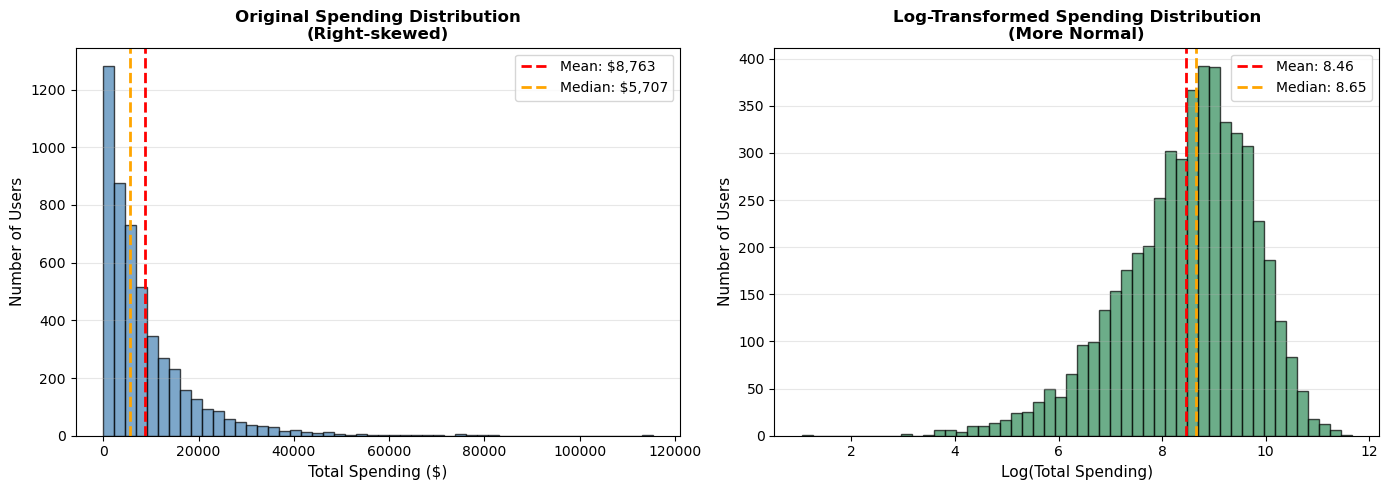

In [ ]:
# Log-transform spending
# Create log-transformed spending
analysis_df_clean['log_spend'] = np.log(analysis_df_clean['total_spend'] + 1)

# standardize z-score
from scipy.stats import zscore

analysis_df_clean['log_spend_std'] = zscore(analysis_df_clean['log_spend'])
analysis_df_clean['num_categories_std'] = zscore(analysis_df_clean['num_categories'])
analysis_df_clean['days_since_purchase_std'] = zscore(analysis_df_clean['days_since_purchase'])

print(f"Original spending: Mean=${analysis_df_clean['total_spend'].mean():,.2f}, Median=${analysis_df_clean['total_spend'].median():,.2f}")
print(f"Log-transformed: Mean={analysis_df_clean['log_spend'].mean():.2f}, Median={analysis_df_clean['log_spend'].median():.2f}")

# Log-transform visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original spending distribution
axes[0].hist(analysis_df_clean['total_spend'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Spending ($)', fontsize=11)
axes[0].set_ylabel('Number of Users', fontsize=11)
axes[0].set_title('Original Spending Distribution\n(Right-skewed)', fontsize=12, fontweight='bold')
axes[0].axvline(analysis_df_clean['total_spend'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${analysis_df_clean["total_spend"].mean():,.0f}')
axes[0].axvline(analysis_df_clean['total_spend'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: ${analysis_df_clean["total_spend"].median():,.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Log-transformed spending distribution
axes[1].hist(analysis_df_clean['log_spend'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Total Spending)', fontsize=11)
axes[1].set_ylabel('Number of Users', fontsize=11)
axes[1].set_title('Log-Transformed Spending Distribution\n(More Normal)', fontsize=12, fontweight='bold')
axes[1].axvline(analysis_df_clean['log_spend'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {analysis_df_clean["log_spend"].mean():.2f}')
axes[1].axvline(analysis_df_clean['log_spend'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {analysis_df_clean["log_spend"].median():.2f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<a id='3-eda'></a>
## 3. Exploratory Data Analysis
> Visualization of the relationship between behavioral factors and privacy attitudes
---


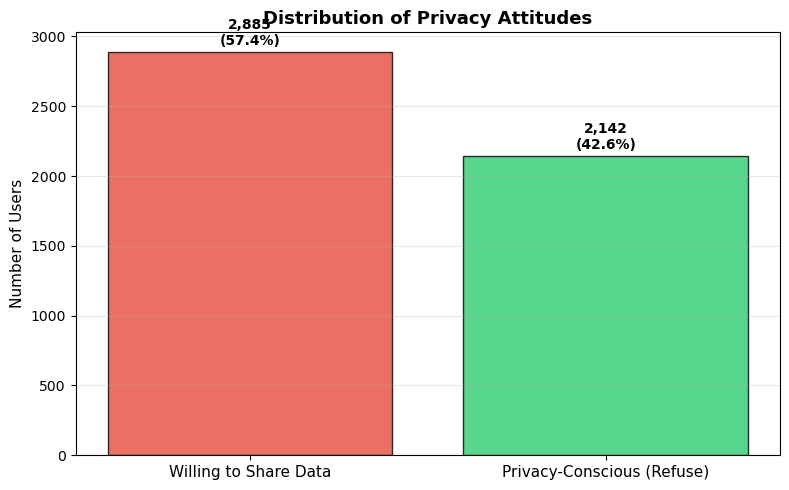

In [56]:
# 1. Outcome Variable Distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

privacy_counts = analysis_df_clean['privacy_concerned'].value_counts()
colors = ['#e74c3c', '#2ecc71']
labels = ['Willing to Share Data', 'Privacy-Conscious (Refuse)']

ax.bar(range(len(privacy_counts)), privacy_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(privacy_counts)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_title('Distribution of Privacy Attitudes', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(privacy_counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(analysis_df_clean)*100:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

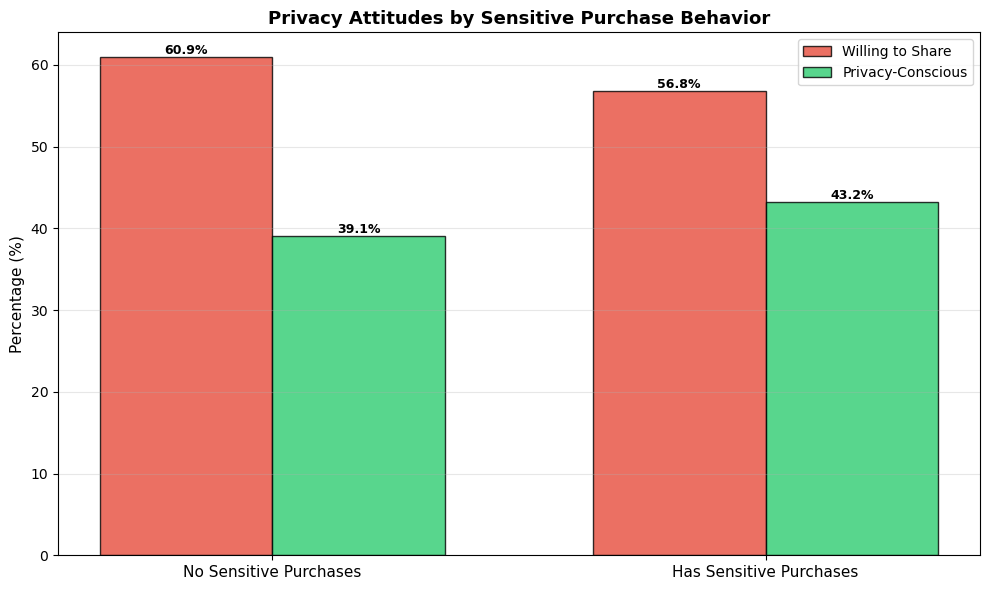


Chi-square test: χ² = 4.36, p = 0.0369
Sensitive purchases and privacy attitudes associated


In [ ]:
    
# 2. Sensitive Purchases vs Privacy Attitudes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

crosstab = pd.crosstab(analysis_df_clean['has_sensitive_purchases'], 
                       analysis_df_clean['privacy_concerned'], 
                       normalize='index') * 100

# Plot bars
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, crosstab[0], width, label='Willing to Share', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, crosstab[1], width, label='Privacy-Conscious', color='#2ecc71', alpha=0.8, edgecolor='black')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Privacy Attitudes by Sensitive Purchase Behavior', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['No Sensitive Purchases', 'Has Sensitive Purchases'], fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Chi-square test
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(
    analysis_df_clean['has_sensitive_purchases'], 
    analysis_df_clean['privacy_concerned']
))
print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Sensitive purchases and privacy attitudes associated")
else:
    print("No significant association")

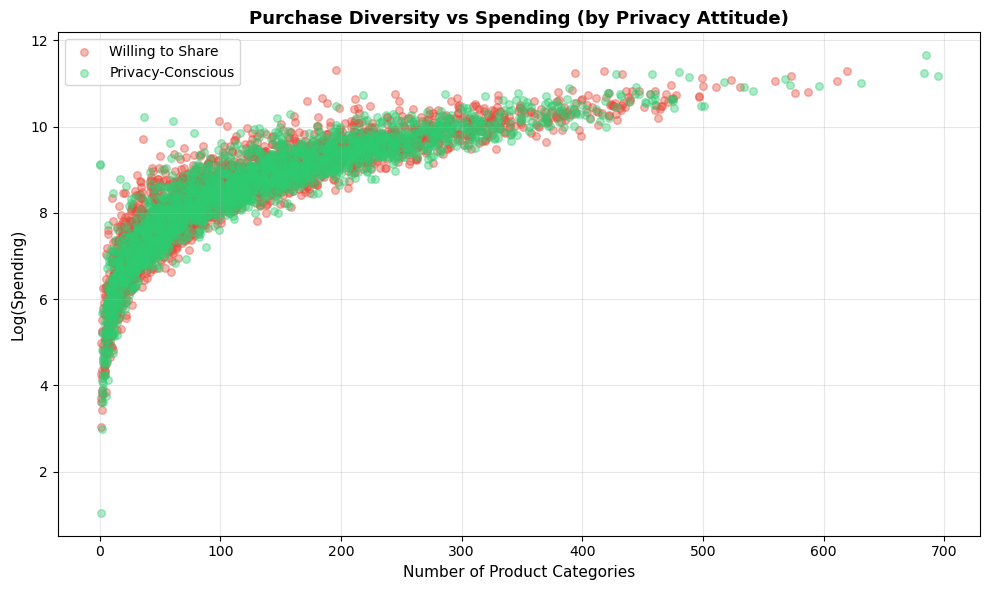


Average categories purchased:
  Willing to share: 129.5
  Privacy-conscious: 135.4


In [ ]:
# 3. Purchase Diversity 
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Scatter plot
privacy_0 = analysis_df_clean[analysis_df_clean['privacy_concerned']==0]
privacy_1 = analysis_df_clean[analysis_df_clean['privacy_concerned']==1]

ax.scatter(privacy_0['num_categories'] + np.random.normal(0, 0.1, len(privacy_0)), 
           privacy_0['log_spend'], alpha=0.4, s=30, label='Willing to Share', color='#e74c3c')
ax.scatter(privacy_1['num_categories'] + np.random.normal(0, 0.1, len(privacy_1)), 
           privacy_1['log_spend'], alpha=0.4, s=30, label='Privacy-Conscious', color='#2ecc71')

ax.set_xlabel('Number of Product Categories', fontsize=11)
ax.set_ylabel('Log(Spending)', fontsize=11)
ax.set_title('Purchase Diversity vs Spending (by Privacy Attitude)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage categories purchased:")
print(f"  Willing to share: {privacy_0['num_categories'].mean():.1f}")
print(f"  Privacy-conscious: {privacy_1['num_categories'].mean():.1f}")

<a id='4-modeling'></a>
## 4. Model Building for Logistic Regresssion
---

In [61]:
# Prepare Data for Modeling
age_dummies = pd.get_dummies(analysis_df_clean['Q-demos-age'], prefix='age', drop_first=True, dtype=int)
edu_dummies = pd.get_dummies(analysis_df_clean['Q-demos-education'], prefix='edu', drop_first=True, dtype=int)
income_dummies = pd.get_dummies(analysis_df_clean['Q-demos-income'], prefix='income', drop_first=True, dtype=int)

model_data = pd.concat([
    analysis_df_clean[['privacy_concerned', 'log_spend', 'has_sensitive_purchases', 
                       'num_categories', 'days_since_purchase']].astype(float),
    age_dummies,
    edu_dummies,
    income_dummies
], axis=1)

In [62]:
# Model 1 (Control Model)
y = model_data['privacy_concerned'].values.astype(float)
X1 = model_data[age_dummies.columns.tolist() + edu_dummies.columns.tolist() + income_dummies.columns.tolist()].values.astype(float)
X1 = sm.add_constant(X1)

model1 = sm.Logit(y, X1)
results1 = model1.fit(disp=0)

In [63]:
# Model 2 (Total Spending)
X2_df = pd.concat([
    model_data[['log_spend']],
    model_data[age_dummies.columns.tolist() + edu_dummies.columns.tolist() + income_dummies.columns.tolist()]
], axis=1)
X2 = sm.add_constant(X2_df.values.astype(float))

model2 = sm.Logit(y, X2)
results2 = model2.fit(disp=0)


In [64]:
# Model 3 (Sensitive Purchases)
X3_df = pd.concat([
    model_data[['log_spend', 'has_sensitive_purchases']],
    model_data[age_dummies.columns.tolist() + edu_dummies.columns.tolist() + income_dummies.columns.tolist()]
], axis=1)
X3 = sm.add_constant(X3_df.values.astype(float))

model3 = sm.Logit(y, X3)
results3 = model3.fit(disp=0)

In [65]:
# Model 4 (Purchase Diversity)
X4_df = pd.concat([
    model_data[['log_spend', 'has_sensitive_purchases', 'num_categories']],
    model_data[age_dummies.columns.tolist() + edu_dummies.columns.tolist() + income_dummies.columns.tolist()]
], axis=1)
X4 = sm.add_constant(X4_df.values.astype(float))

model4 = sm.Logit(y, X4)
results4 = model4.fit(disp=0)


In [ ]:
# Model 5 (Full Model)
model_data = pd.concat([
    analysis_df_clean[['privacy_concerned', 'log_spend_std', 'has_sensitive_purchases', 
                       'num_categories_std', 'days_since_purchase_std']].astype(float),
    age_dummies,
    edu_dummies,
    income_dummies
], axis=1)
X5 = sm.add_constant(X5_df.values.astype(float))

model5 = sm.Logit(y, X5)
results5 = model5.fit(disp=0)

In [67]:
# Model Comparison 
comparison = pd.DataFrame({
    'Model': ['1. Demographics Only', '2. + Spending', '3. + Sensitive', 
              '4. + Diversity', '5. Full Model'],
    'McFadden R²': [results1.prsquared, results2.prsquared, results3.prsquared, 
                     results4.prsquared, results5.prsquared],
    'AIC': [results1.aic, results2.aic, results3.aic, results4.aic, results5.aic],
    'Log-Likelihood': [results1.llf, results2.llf, results3.llf, results4.llf, results5.llf]
})

print(comparison.round(3).to_string(index=False))
print(f"\nBest model: {comparison.loc[comparison['AIC'].idxmin(), 'Model']}")

final_model_X = X5_df
final_model_results = results5

               Model  McFadden R²      AIC  Log-Likelihood
1. Demographics Only        0.019 6761.908       -3364.954
       2. + Spending        0.019 6763.277       -3364.638
      3. + Sensitive        0.019 6761.853       -3362.926
      4. + Diversity        0.021 6755.960       -3358.980
       5. Full Model        0.021 6755.023       -3357.512

Best model: 5. Full Model


<a id='5-results'></a>
## 5. Results
---

In [68]:
n_behavioral = 5  
coefs = final_model_results.params[:n_behavioral]
std_errors = final_model_results.bse[:n_behavioral]
pvalues = final_model_results.pvalues[:n_behavioral]
conf_int = final_model_results.conf_int()[:n_behavioral]

# Create results table
var_names = ['Intercept', 'Log(Spending)', 'Sensitive Purchases', 'Num Categories', 'Days Since Purchase']

# Confidence intervals
ci_array = final_model_results.conf_int()

results_df = pd.DataFrame({
    'Variable': var_names,
    'Coefficient': coefs,
    'Std Error': std_errors,
    'p-value': pvalues,
    'Odds Ratio': np.exp(coefs),
    '95% CI Lower': np.exp(ci_array[:n_behavioral, 0]),
    '95% CI Upper': np.exp(ci_array[:n_behavioral, 1])
})
# Behavioral variables
behavioral_results = results_df.iloc[1:]

print("\n")
print(behavioral_results.round(4).to_string(index=False))



           Variable  Coefficient  Std Error  p-value  Odds Ratio  95% CI Lower  95% CI Upper
      Log(Spending)      -0.1650     0.0467   0.0004      0.8479        0.7737        0.9291
Sensitive Purchases       0.1799     0.0961   0.0612      1.1971        0.9916        1.4451
     Num Categories       0.0015     0.0005   0.0031      1.0015        1.0005        1.0025
Days Since Purchase      -0.0004     0.0002   0.0892      0.9996        0.9992        1.0001


---
### Hypothesis Test Results

In [96]:

for idx in range(1, 5):  # Skip intercept
    var = results_df.iloc[idx]
    
    print(f"\n**H{idx}: {var['Variable']}**")
    print(f"  Odds Ratio: {var['Odds Ratio']:.3f}")
    print(f"  95% CI: ({var['95% CI Lower']:.3f}, {var['95% CI Upper']:.3f})")
    print(f"  p-value: {var['p-value']:.4f}")
    
    if var['p-value'] < 0.05:
        if var['Odds Ratio'] > 1:
            pct = (var['Odds Ratio'] - 1) * 100
            print(f"  SIGNIFICANT: Associated with {pct:.1f}% HIGHER odds of privacy concern")
        else:
            pct = (1 - var['Odds Ratio']) * 100
            print(f"  SIGNIFICANT: Associated with {pct:.1f}% LOWER odds of privacy concern")
    else:
        print(f"  NOT SIGNIFICANT: No evidence of association")



**H1: Log(Spending)**
  Odds Ratio: 0.848
  95% CI: (0.774, 0.929)
  p-value: 0.0004
  SIGNIFICANT: Associated with 15.2% LOWER odds of privacy concern

**H2: Sensitive Purchases**
  Odds Ratio: 1.197
  95% CI: (0.992, 1.445)
  p-value: 0.0612
  NOT SIGNIFICANT: No evidence of association

**H3: Num Categories**
  Odds Ratio: 1.002
  95% CI: (1.001, 1.003)
  p-value: 0.0031
  SIGNIFICANT: Associated with 0.2% HIGHER odds of privacy concern

**H4: Days Since Purchase**
  Odds Ratio: 1.000
  95% CI: (0.999, 1.000)
  p-value: 0.0892
  NOT SIGNIFICANT: No evidence of association


---
### Visualize Odds Ratios

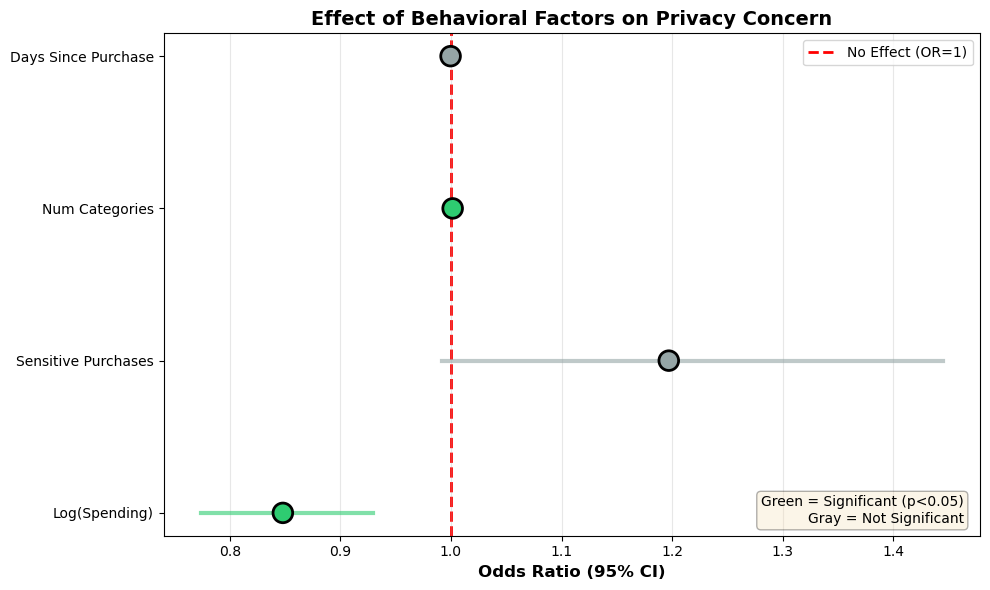

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract data for plotting 
plot_data = behavioral_results.copy()
vars_to_plot = plot_data['Variable'].values
ors = plot_data['Odds Ratio'].values
ci_lower = plot_data['95% CI Lower'].values
ci_upper = plot_data['95% CI Upper'].values
p_vals = plot_data['p-value'].values

# Color by significance
colors = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in p_vals]

y_pos = np.arange(len(vars_to_plot))
ax.scatter(ors, y_pos, s=200, c=colors, zorder=3, edgecolors='black', linewidth=2)

# Add confidence intervals
for i in range(len(vars_to_plot)):
    ax.plot([ci_lower[i], ci_upper[i]], [y_pos[i], y_pos[i]], 
            color=colors[i], linewidth=3, alpha=0.6, zorder=2)

# Add reference line at OR = 1
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='No Effect (OR=1)', zorder=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(vars_to_plot)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Behavioral Factors on Privacy Concern', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.legend()

# Add interpretation guide
ax.text(0.98, 0.02, 'Green = Significant (p<0.05)\nGray = Not Significant', 
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


In [100]:
print(f"\nSample size: {len(y):,} users")
print(f"McFadden R²: {final_model_results.prsquared:.4f}")
print(f"Log-Likelihood: {final_model_results.llf:.2f}")
print(f"AIC: {final_model_results.aic:.1f}")
print(f"BIC: {final_model_results.bic:.1f}")
print(f"\nOverall model significance:")
print(f"  Likelihood Ratio χ²({final_model_results.df_model}) = {final_model_results.llr:.2f}")
print(f"  p < 0.001")
print(f"  Model is significantly better than null model")
print("\n --------------------------------------------------------")
pub_table = behavioral_results[['Variable', 'Odds Ratio', 'p-value']].copy()
pub_table['95% CI'] = [f"({behavioral_results.iloc[i]['95% CI Lower']:.2f}, {behavioral_results.iloc[i]['95% CI Upper']:.2f})" 
                       for i in range(len(behavioral_results))]
pub_table['p-value'] = pub_table['p-value'].apply(lambda x: '<.001' if x < 0.001 else f'{x:.3f}')
pub_table['Odds Ratio'] = pub_table['Odds Ratio'].round(2)
pub_table['Sig'] = ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                    for p in behavioral_results['p-value']]

final_table = pub_table[['Variable', 'Odds Ratio', '95% CI', 'p-value', 'Sig']]

print("\n" + final_table.to_string(index=False))



Sample size: 5,027 users
McFadden R²: 0.0209
Log-Likelihood: -3357.51
AIC: 6755.0
BIC: 6885.5

Overall model significance:
  Likelihood Ratio χ²(19.0) = 143.66
  p < 0.001
  Model is significantly better than null model

 --------------------------------------------------------

           Variable  Odds Ratio       95% CI p-value Sig
      Log(Spending)        0.85 (0.77, 0.93)   <.001 ***
Sensitive Purchases        1.20 (0.99, 1.45)   0.061    
     Num Categories        1.00 (1.00, 1.00)   0.003  **
Days Since Purchase        1.00 (1.00, 1.00)   0.089    


<a id='6-diagnostics'></a>
## 6. Model Diagnostics
---

In [98]:
#1. Multicollinearity Check (VIF)
behavioral_X = model_data[['log_spend_std', 'has_sensitive_purchases', 'num_categories_std', 'days_since_purchase_std']]

vif_data = pd.DataFrame()
vif_data['Variable'] = behavioral_X.columns
vif_data['VIF'] = [variance_inflation_factor(behavioral_X.values, i) for i in range(behavioral_X.shape[1])]

print("\n")
print(vif_data.to_string(index=False))

print("\nInterpretation:")
print("  VIF < 5: No multicollinearity concerns")
print("  VIF 5-10: Moderate multicollinearity")
print("  VIF > 10: Severe multicollinearity (problematic)")

max_vif = vif_data['VIF'].max()
if max_vif < 5:
    print(f"\n No multicollinearity issues (max VIF = {max_vif:.2f})")
elif max_vif < 10:
    print(f"\n Moderate multicollinearity (max VIF = {max_vif:.2f})")
else:
    print(f"\n Severe multicollinearity (max VIF = {max_vif:.2f})")




               Variable      VIF
          log_spend_std 3.641686
has_sensitive_purchases 1.041520
     num_categories_std 3.306773
days_since_purchase_std 1.188177

Interpretation:
  VIF < 5: No multicollinearity concerns
  VIF 5-10: Moderate multicollinearity
  VIF > 10: Severe multicollinearity (problematic)

 No multicollinearity issues (max VIF = 3.64)


In [101]:
# Use 0.5 threshold
predicted_class = (predicted_probs >= 0.5).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

cm = confusion_matrix(y, predicted_class)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                 Predicted 0  Predicted 1")
print(f"Actual 0 (Willing)    {tn:6d}      {fp:6d}")
print(f"Actual 1 (Concerned)  {fn:6d}      {tp:6d}")
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

# ROC AUC
try:
    auc = roc_auc_score(y, predicted_probs)
    print(f"ROC AUC:   {auc:.3f}")
except:
    print("ROC AUC: Could not calculate")

print("\nInterpretation:")
if accuracy > 0.6:
    print("  Model has decent classification performance")
else:
    print("  Low classification accuracy - may not be useful for prediction")
    


Confusion Matrix:
                 Predicted 0  Predicted 1
Actual 0 (Willing)      2482         403
Actual 1 (Concerned)    1624         518

Accuracy:  0.597
Precision: 0.562
Recall:    0.242
F1 Score:  0.338
ROC AUC:   0.596

Interpretation:
  Low classification accuracy - may not be useful for prediction


<a id='7-conclusions'></a>
## 7. Summary

---
### Key Findings Summary

This analysis examined whether Amazon shopping behavior predicts privacy attitudes, controlling for demographic factors. Using logistic regression on 5,027 users, this study tested four behavioral hypotheses:

**1. TOTAL SPENDING (SUPPORTED - Counter-intuitive finding)**
- Heavier spenders are 15% LESS likely to be privacy-conscious
- OR = 0.85, p < 0.001
- **Finding:** Users deeply embedded in Amazon ecosystem have accepted the privacy trade-off for convenience

**2. SENSITIVE PURCHASES (Marginal support)**
- Users who buy health/beauty products show 20% higher privacy concern
- OR = 1.20, p = 0.061 (trending toward significance)
- **Finding:** Weak evidence that product sensitivity matters

**3. PURCHASE DIVERSITY (Not supported)**
- Number of categories shopped has negligible effect
- OR ≈ 1.00, p = 0.003 (significant but meaningless effect size)
- **Finding:** How MUCH you spend matters, not how diversely

**4. PURCHASE RECENCY (Not supported)**
- Days since last purchase shows no relationship
- OR = 1.00, p = 0.089
- **Finding:** Timing of purchases irrelevant to privacy attitudes

---


### Final Conclusion

This analysis demonstrates that shopping behavior predicts privacy attitudes, though the relationship is modest (R² = 0.02). The key finding - that heavy spenders are LESS privacy-conscious - challenges assumptions and has clear business implications.

**What This Project Demonstrates:**
- Rigorous hypothesis testing using logistic regression
- Proper statistical inference with odds ratios and confidence intervals
- Control for demographic confounders


This project demonstrates the value of statistical inference for understanding customer behavior, even when predictive accuracy is modest.

---